In [1]:
import re
from pathlib import Path
from zipfile import ZipFile
from xml.etree import ElementTree as ET

import cobra
import pandas as pd
from cobra import Metabolite, Reaction
from cobra.flux_analysis import production_envelope

# Paths work whether the notebook is launched from iBag/ or the repo root.
def first_existing_path(*candidates):
    for candidate in candidates:
        path = Path(candidate)
        if path.exists():
            return path
    raise FileNotFoundError(f"None of these paths exist: {candidates}")

MODEL_PATH = first_existing_path("ModelFiles/iBag597.xml", "iBag/ModelFiles/iBag597.xml")
METABOLITE_TABLE_PATH = first_existing_path("../ecoli_20_modules_sg/metabolite_table.csv", "ecoli_20_modules_sg/metabolite_table.csv")
IBAG_BIGG_PATH = first_existing_path("iBag597BiGG.xlsx", "iBag/iBag597BiGG.xlsx")

# Reload a clean base model before adding workbook reactions.
model = cobra.io.read_sbml_model(str(MODEL_PATH))

NATIVE_METABOLITE_MAP = {
    "ac_c": "Acetate[c]",
    "acald_c": "Acetaldehyde[c]",
    "accoa_c": "Acetyl_CoA[c]",
    "actp_c": "Acetylphosphate[c]",
    "adp_c": "ADP[c]",
    "akg_c": "2_Oxoglutarate[c]",
    "asp__L_c": "L_Aspartate[c]",
    "atp_c": "ATP[c]",
    "btcoa_c": "Butanoyl_CoA[c]",
    "co2_c": "CO2[c]",
    "coa_c": "CoA[c]",
    "etoh_c": "Ethanol[c]",
    "glu__L_c": "L_Glutamate[c]",
    "h2o_c": "H2O[c]",
    "h_c": "H+[c]",
    "hom__L_c": "L_Homoserine[c]",
    "lac__D_c": "D_Lactate[c]",
    "nad_c": "NAD[c]",
    "nadh_c": "NADH[c]",
    "nadp_c": "NADP[c]",
    "nadph_c": "NADPH[c]",
    "nh4_c": "NH3[c]",
    "oaa_c": "Oxaloacetate[c]",
    "phom_c": "O_Phospho_L_homoserine[c]",
    "pi_c": "Phosphate[c]",
    "ppcoa_c": "Propanoyl_CoA[c]",
    "pyr_c": "Pyruvate[c]",
    "succ_c": "Succinate[c]",
    "succoa_c": "Succinyl_CoA[c]",
    "thr__L_c": "L_Threonine[c]",
}

REACTION_ARROW_RE = re.compile(r"\s*(<=>|=>|-->)\s*")
TERM_RE = re.compile(r"^\s*(?:(-?\d+(?:\.\d+)?)\s+)?([A-Za-z0-9_]+_[a-z])\s*$")
REACTION_SPAN_RE = re.compile(
    r"[A-Za-z0-9_]+_[a-z](?:\s*\+\s*(?:-?\d+(?:\.\d+)?\s+)?[A-Za-z0-9_]+_[a-z])*"
    r"\s*(?:<=>|=>|-->)\s*"
    r"(?:-?\d+(?:\.\d+)?\s+)?[A-Za-z0-9_]+_[a-z](?:\s*\+\s*(?:-?\d+(?:\.\d+)?\s+)?[A-Za-z0-9_]+_[a-z])*"
)
XLSX_NS = {"a": "http://schemas.openxmlformats.org/spreadsheetml/2006/main"}

def load_metabolite_table(path):
    df = pd.read_csv(path)
    return {str(row["id"]): row.to_dict() for _, row in df.iterrows()}

def xlsx_shared_strings(archive):
    if "xl/sharedStrings.xml" not in archive.namelist():
        return []
    root = ET.fromstring(archive.read("xl/sharedStrings.xml"))
    return ["".join(t.text or "" for t in item.findall(".//a:t", XLSX_NS)) for item in root.findall("a:si", XLSX_NS)]

def xlsx_cell_value(cell, shared_strings):
    value = cell.find("a:v", XLSX_NS)
    if value is None or value.text is None:
        return ""
    if cell.attrib.get("t") == "s":
        return shared_strings[int(value.text)]
    return value.text

def column_index(cell_ref):
    letters = re.match(r"[A-Z]+", cell_ref)
    if not letters:
        return 0
    index = 0
    for letter in letters.group(0):
        index = index * 26 + ord(letter) - ord("A") + 1
    return index - 1

def read_first_sheet_xlsx(path):
    with ZipFile(path) as archive:
        shared_strings = xlsx_shared_strings(archive)
        workbook = ET.fromstring(archive.read("xl/workbook.xml"))
        first_sheet = workbook.find("a:sheets/a:sheet", XLSX_NS)
        rels_root = ET.fromstring(archive.read("xl/_rels/workbook.xml.rels"))
        rels = {rel.attrib["Id"]: rel.attrib["Target"] for rel in rels_root}
        rel_id = first_sheet.attrib["{http://schemas.openxmlformats.org/officeDocument/2006/relationships}id"]
        sheet = ET.fromstring(archive.read("xl/" + rels[rel_id].lstrip("/")))
        rows = []
        for row in sheet.findall(".//a:sheetData/a:row", XLSX_NS):
            values = []
            for cell in row.findall("a:c", XLSX_NS):
                index = column_index(cell.attrib.get("r", "A1"))
                while len(values) <= index:
                    values.append("")
                values[index] = xlsx_cell_value(cell, shared_strings).strip()
            rows.append(values)
    headers = rows[0]
    return [dict(zip(headers, row + [""] * (len(headers) - len(row)))) for row in rows[1:]]

def normalized_key(row, wanted):
    wanted_norm = re.sub(r"[^a-z0-9]", "", wanted.lower())
    for key in row:
        if re.sub(r"[^a-z0-9]", "", key.lower()) == wanted_norm:
            return key
    raise KeyError(f"Column not found: {wanted}")

def sanitize_reaction_id(value):
    return str(value or "").strip().split(",", 1)[0].strip()

def sanitize_reaction_string(value):
    text = str(value or "").strip().rstrip(",")
    matches = REACTION_SPAN_RE.findall(text)
    return matches[-1].strip().rstrip(",") if matches else text

def clean_annotation_value(value):
    text = str(value or "").strip()
    return "" if text.upper() == "NONE" else text

def load_heterologous_reaction_table(path):
    rows = read_first_sheet_xlsx(path)
    if not rows:
        return pd.DataFrame(columns=["id", "name", "rxn_str", "kegg_id", "bigg_id"])
    sample = rows[0]
    id_col = normalized_key(sample, "Abbreviation csv")
    name_col = normalized_key(sample, "name")
    rxn_col = normalized_key(sample, "rxn csv")
    ibag_col = normalized_key(sample, "Abbrevation iBag")
    kegg_col = normalized_key(sample, "KEGG id")
    bigg_col = normalized_key(sample, "BiGG id")
    reaction_rows = []
    for row in rows:
        if row.get(ibag_col, "").strip().upper() != "NONE":
            continue
        reaction_rows.append({
            "id": sanitize_reaction_id(row.get(id_col, "")),
            "name": row.get(name_col, "").strip(),
            "rxn_str": sanitize_reaction_string(row.get(rxn_col, "")),
            "kegg_id": clean_annotation_value(row.get(kegg_col, "")),
            "bigg_id": clean_annotation_value(row.get(bigg_col, "")),
        })
    return pd.DataFrame(reaction_rows)

def model_metabolite_id(bigg_id):
    if bigg_id in NATIVE_METABOLITE_MAP:
        return NATIVE_METABOLITE_MAP[bigg_id]
    if bigg_id.endswith("_c"):
        return f"{bigg_id[:-2]}[c]"
    if bigg_id.endswith("_e"):
        return f"{bigg_id[:-2]}[e]"
    return bigg_id

def ensure_metabolite(model, bigg_id, met_table):
    mapped_id = model_metabolite_id(bigg_id)
    if mapped_id in model.metabolites:
        return model.metabolites.get_by_id(mapped_id)
    bare_id = bigg_id.rsplit("_", 1)[0]
    row = met_table.get(bare_id, {})
    charge = row.get("charge")
    charge = int(float(charge)) if charge is not None and pd.notna(charge) else None
    met = Metabolite(
        mapped_id,
        name=str(row.get("name") or bare_id),
        formula=None if pd.isna(row.get("formula")) else row.get("formula"),
        charge=charge,
        compartment="c" if bigg_id.endswith("_c") else "e",
    )
    kegg_id = row.get("kegg_id")
    if kegg_id is not None and pd.notna(kegg_id) and str(kegg_id).strip():
        met.annotation["kegg.compound"] = str(kegg_id).strip()
    model.add_metabolites([met])
    return met

def parse_reaction_stoichiometry(rxn_str, model, met_table):
    parts = REACTION_ARROW_RE.split(rxn_str, maxsplit=1)
    if len(parts) != 3:
        raise ValueError(f"Cannot parse reaction string: {rxn_str}")
    left, arrow, right = parts
    stoich = {}
    def add_side(side, sign):
        for term in side.split("+"):
            term = term.strip()
            if not term:
                continue
            match = TERM_RE.match(term)
            if not match:
                raise ValueError(f"Cannot parse reaction term '{term}' in '{rxn_str}'")
            coeff = float(match.group(1) or 1.0)
            met = ensure_metabolite(model, match.group(2), met_table)
            stoich[met] = stoich.get(met, 0.0) + sign * coeff
    add_side(left, -1.0)
    add_side(right, 1.0)
    return stoich, arrow == "<=>"

def add_reaction_table_to_model(model, rxn_df, met_table):
    before_mets = len(model.metabolites)
    added_rxns = 0
    for _, row in rxn_df.iterrows():
        rid = row["id"]
        if rid in model.reactions:
            continue
        stoich, reversible = parse_reaction_stoichiometry(row["rxn_str"], model, met_table)
        rxn = Reaction(rid)
        rxn.name = str(row.get("name") or rid)
        rxn.lower_bound = -1000.0 if reversible else 0.0
        rxn.upper_bound = 1000.0
        rxn.add_metabolites(stoich)
        if row.get("kegg_id"):
            rxn.annotation["kegg.reaction"] = row["kegg_id"]
        if row.get("bigg_id"):
            rxn.annotation["bigg.reaction"] = row["bigg_id"]
        model.add_reactions([rxn])
        added_rxns += 1
    return added_rxns, len(model.metabolites) - before_mets

met_table = load_metabolite_table(METABOLITE_TABLE_PATH)
heterologous_rxn_df = load_heterologous_reaction_table(IBAG_BIGG_PATH)
added_rxns, added_mets = add_reaction_table_to_model(model, heterologous_rxn_df, met_table)
heterologous_rxns = set(heterologous_rxn_df["id"])

imbalanced_heterologous_rxns = {
    rid: model.reactions.get_by_id(rid).check_mass_balance()
    for rid in heterologous_rxns
    if rid in model.reactions and model.reactions.get_by_id(rid).check_mass_balance()
}

print(f"Loaded {added_rxns}/{len(heterologous_rxns)} heterologous reactions from {IBAG_BIGG_PATH}")
print(f"Added {added_mets} metabolites")
print(f"Imbalanced loaded reactions: {len(imbalanced_heterologous_rxns)}")
heterologous_rxn_df[["id", "name", "rxn_str"]]



Loaded 38/38 heterologous reactions from iBag597BiGG.xlsx
Added 39 metabolites
Imbalanced loaded reactions: 16


,id,name,rxn_str
0,BTCOARx,Butyryl-coA reductase (NADH),btcoa_c + h_c + nadh_c <=> btal_c + coa_c + nad_c
1,ALCD3ir,Alcohol dehydrogenase Propanal,h_c + nadh_c + ppal_c <=> nad_c + ppoh_c
2,OIVD2,2-oxoisovalerate dehydrogenase (acylating; 3-m...,3mob_c + coa_c + nad_c => co2_c + nadh_c + ibc...
3,LDH_D,D-lactate dehydrogenase,lac__D_c + nad_c <=> h_c + nadh_c + pyr_c
4,ALDD3procoa,Alcohol dehydrogenase Propanal,nadh_c + h_c + ppcoa_c => nad_c + ppal_c + coa_c
5,IBUTCOA,Isobutyryl-coA reductase (NADH),ibcoa_c + h_c + nadh_c => 2mppal_c + coa_c + ...
6,ALCDptoh,Aldehyde dehydrogenase pentanoyl alcohol NAD,h_c + nadh_c + ptal_c => nad_c + ptoh_c
7,PTCOAR,Pentanoyl-CoA reductase (NADH),ptcoa_c + h_c + nadh_c => ptal_c + coa_c + nad_c
8,VCOAD2,Acyl-CoA dehydrogenase (pentanoyl-CoA) (NADH),h_c + nadh_c + pt2coa_c <=> nad_c + ptcoa_c
9,SSCOARx,Succinyl-coA reductase (NADH),h_c + nadh_c + succoa_c => coa_c + nad_c + suc...


In [2]:
import matplotlib.pyplot as plt

In [3]:
# Quick check to ensure the model and heterologous workbook reactions loaded properly
print(f"Model: {model.id}")
print(f"Reactions: {len(model.reactions)}")
print(f"Metabolites: {len(model.metabolites)}")
print(f"Workbook heterologous reactions: {len(heterologous_rxn_df)}")
print(f"Tracked heterologous reactions: {len(heterologous_rxns)}")
missing_heterologous = sorted(rid for rid in heterologous_rxns if rid not in model.reactions)
print(f"Missing heterologous reactions from model: {missing_heterologous}")
print("Sample loaded heterologous reactions:", sorted(heterologous_rxns)[:12])


Model: COBRAModel
Reactions: 796
Metabolites: 672
Workbook heterologous reactions: 38
Tracked heterologous reactions: 38
Missing heterologous reactions from model: []
Sample loaded heterologous reactions: ['3OXCOAT', '4HBACT', '4HBDH', '4HBTALDDH', 'AATbtylbte', 'AATetylace', 'AATetylbte', 'AATetylpte', 'AATibutylace', 'AATibutylbte', 'AATibutylpte', 'AATppylace']


In [4]:
for rxn in model.reactions:
    print(rxn)

NGAM: ATP[c] + H2O[c] --> ADP[c] + Phosphate[c]
Biomass: 0.165 AMP[c] + 71.94 ATP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 71.94 H2O[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cysteine[c] + 0.2382 L_Glutamate[c] + 0.3595 L_Glutamine[c] + 0.0844 L_Histidine[c] + 0.0671 L_Isoleucine[c] + 0.1822 L_Leucine[c] + 0.1956 L_Lysine[c] + 0.0617 L_Methionine[c] + 0.0866 L_Phenylalanine[c] + 0.4334 L_Proline[c] + 0.1228 L_Serine[c] + 0.0814 L_Threonine[c] + 0.0472 L_Tryptophan[c] + 0.0646 L_Tyrosine[c] + 0.0922 L_Valine[c] + 0.0375 Lipid[c] + 0.0176 Lipoteichoic_acid[c] + 0.119 Peptidoglycan[c] + Polysaccharide[c] + 0.136 UMP[c] + 0.0967 dAMP[c] + 0.084 dCMP[c] + 0.084 dGMP[c] + 0.0967 dTMP[c] --> 71.94 ADP[c] + Biomass[c] + 71.94 Phosphate[c]
GAM: 0.165 AMP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cyst

In [5]:
for ex in model.exchanges:
    if ex.lower_bound < 0:
        print(ex)

# exception for thiamin

EX0001: Glucose[e] <=> 
EX0004: O2[e] <=> 
EX0005: NH3[e] <=> 
EX0006: Phosphate[e] <=> 
EX0007: Sulfate[e] <=> 
EX0008: Thiamin[e] <=> 
EX0009: Fe2+[e] <=> 
EX0010: Folate[e] <=> 
EX0011: Guanine[e] <=> 
EX0012: H+[e] <=> 
EX0013: H2O[e] <=> 
EX0014: L_Alanine[e] <=> 
EX0015: L_Arginine[e] <=> 
EX0016: L_Cysteine[e] <=> 
EX0017: L_Glutamate[e] <=> 
EX0018: L_Histidine[e] <=> 
EX0019: L_Isoleucine[e] <=> 
EX0020: L_Leucine[e] <=> 
EX0021: L_Methionine[e] <=> 
EX0022: L_Threonine[e] <=> 
EX0023: L_Valine[e] <=> 
EX0024: L_Tyrosine[e] <=> 


In [6]:
# Heterologous reactions are loaded in the first cell so early reaction checks include them.
print(f"Workbook heterologous reactions loaded: {len(heterologous_rxn_df)}")
print(f"Heterologous reaction ids tracked: {len(heterologous_rxns)}")
print(f"Current model reactions: {len(model.reactions)}")
heterologous_rxn_df[["id", "name", "rxn_str"]]



Workbook heterologous reactions loaded: 38
Heterologous reaction ids tracked: 38
Current model reactions: 796


,id,name,rxn_str
0,BTCOARx,Butyryl-coA reductase (NADH),btcoa_c + h_c + nadh_c <=> btal_c + coa_c + nad_c
1,ALCD3ir,Alcohol dehydrogenase Propanal,h_c + nadh_c + ppal_c <=> nad_c + ppoh_c
2,OIVD2,2-oxoisovalerate dehydrogenase (acylating; 3-m...,3mob_c + coa_c + nad_c => co2_c + nadh_c + ibc...
3,LDH_D,D-lactate dehydrogenase,lac__D_c + nad_c <=> h_c + nadh_c + pyr_c
4,ALDD3procoa,Alcohol dehydrogenase Propanal,nadh_c + h_c + ppcoa_c => nad_c + ppal_c + coa_c
5,IBUTCOA,Isobutyryl-coA reductase (NADH),ibcoa_c + h_c + nadh_c => 2mppal_c + coa_c + ...
6,ALCDptoh,Aldehyde dehydrogenase pentanoyl alcohol NAD,h_c + nadh_c + ptal_c => nad_c + ptoh_c
7,PTCOAR,Pentanoyl-CoA reductase (NADH),ptcoa_c + h_c + nadh_c => ptal_c + coa_c + nad_c
8,VCOAD2,Acyl-CoA dehydrogenase (pentanoyl-CoA) (NADH),h_c + nadh_c + pt2coa_c <=> nad_c + ptcoa_c
9,SSCOARx,Succinyl-coA reductase (NADH),h_c + nadh_c + succoa_c => coa_c + nad_c + suc...


In [7]:
def carbon_yield_calcs(model, module_rxn_ids: set, objective_rxn_id: str, heterologous_rxns: set):
    with model:
        # block all heterologous reactions except the active module
        to_block = heterologous_rxns - module_rxn_ids
        for rxn_id in to_block:
            model.reactions.get_by_id(rxn_id).bounds = (0.0, 0.0)

        # Block O2 
        if "EX0004" in model.reactions:
            model.reactions.EX0004.bounds = (0.0, 0.0)

        # Block non-glucose carbon sources
        for ex in model.exchanges:
            met = next(iter(ex.metabolites))
            if met.elements.get("C", 0) and ex.id not in ["EX0001", 'EX0008']:
                ex.lower_bound = 0.0

        model.reactions.EX0001.lower_bound = -1.0

        prod_env = production_envelope(
            model,
            ["EXBiomass"],
            objective=objective_rxn_id,
            carbon_sources=["EX0001"]
        )
    return prod_env

In [8]:
for rxn in model.reactions:
    print(rxn)

NGAM: ATP[c] + H2O[c] --> ADP[c] + Phosphate[c]
Biomass: 0.165 AMP[c] + 71.94 ATP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 71.94 H2O[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cysteine[c] + 0.2382 L_Glutamate[c] + 0.3595 L_Glutamine[c] + 0.0844 L_Histidine[c] + 0.0671 L_Isoleucine[c] + 0.1822 L_Leucine[c] + 0.1956 L_Lysine[c] + 0.0617 L_Methionine[c] + 0.0866 L_Phenylalanine[c] + 0.4334 L_Proline[c] + 0.1228 L_Serine[c] + 0.0814 L_Threonine[c] + 0.0472 L_Tryptophan[c] + 0.0646 L_Tyrosine[c] + 0.0922 L_Valine[c] + 0.0375 Lipid[c] + 0.0176 Lipoteichoic_acid[c] + 0.119 Peptidoglycan[c] + Polysaccharide[c] + 0.136 UMP[c] + 0.0967 dAMP[c] + 0.084 dCMP[c] + 0.084 dGMP[c] + 0.0967 dTMP[c] --> 71.94 ADP[c] + Biomass[c] + 71.94 Phosphate[c]
GAM: 0.165 AMP[c] + 0.126 CMP[c] + 0.2028 GMP[c] + 0.1279 Glycine[c] + 0.1012 L_Alanine[c] + 0.0563 L_Arginine[c] + 0.1767 L_Asparagine[c] + 0.1754 L_Aspartate[c] + 0.2022 L_Cyst

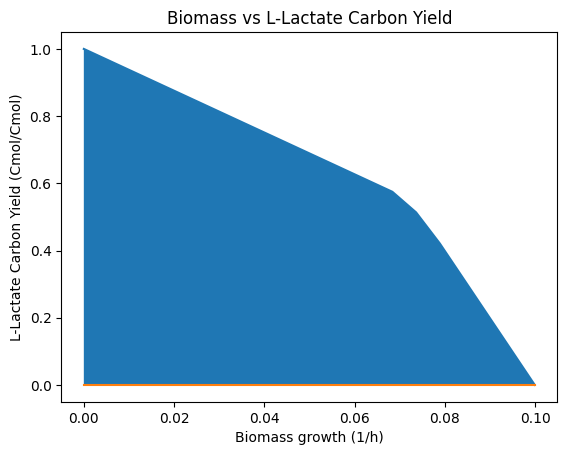

,carbon_source,flux_minimum,carbon_yield_minimum,mass_yield_minimum,flux_maximum,carbon_yield_maximum,mass_yield_maximum,EXBiomass
0,EX0001,0.0,0.0,0.0,2.000000,1.000000e+00,1.000000e+00,0.000000
1,EX0001,0.0,0.0,0.0,1.934591,9.672953e-01,9.672953e-01,0.005258
2,EX0001,0.0,0.0,0.0,1.869181,9.345906e-01,9.345906e-01,0.010516
3,EX0001,0.0,0.0,0.0,1.803772,9.018859e-01,9.018859e-01,0.015774
4,EX0001,0.0,0.0,0.0,1.738362,8.691812e-01,8.691812e-01,0.021032
5,EX0001,0.0,0.0,0.0,1.672953,8.364765e-01,8.364765e-01,0.026290
6,EX0001,0.0,0.0,0.0,1.607544,8.037718e-01,8.037718e-01,0.031548
7,EX0001,0.0,0.0,0.0,1.542134,7.710671e-01,7.710671e-01,0.036806
8,EX0001,0.0,0.0,0.0,1.476725,7.383624e-01,7.383624e-01,0.042064
9,EX0001,0.0,0.0,0.0,1.411315,7.056577e-01,7.056577e-01,0.047322


In [9]:
# EX0002: L_Lactate[e] --> 

prod_env = carbon_yield_calcs(model, set(), 'EX0002', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("L-Lactate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs L-Lactate Carbon Yield")
plt.show()

prod_env.fillna(0)

In [12]:
# PYRDC is not marked as NONE in iBag597BiGG.xlsx, but the ethanol PDC module below uses it.
# Add it separately without replacing the workbook-loaded heterologous_rxns set.
if "PYRDC" not in model.reactions:
    rxn = Reaction("PYRDC")
    rxn.name = "Pyruvate decarboxylase"
    rxn.lower_bound = 0
    rxn.upper_bound = 1000
    rxn.add_metabolites({
        model.metabolites.get_by_id("Pyruvate[c]"): -1,
        model.metabolites.get_by_id("H+[c]"): -1,
        model.metabolites.get_by_id("Acetaldehyde[c]"): 1,
        model.metabolites.get_by_id("CO2[c]"): 1,
    })
    model.add_reactions([rxn])

heterologous_rxns.add("PYRDC")



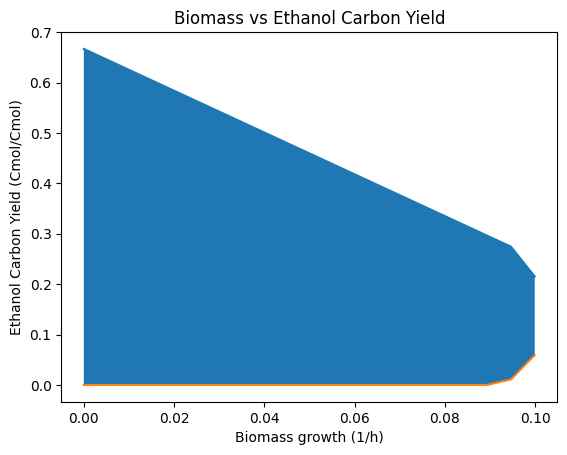

,carbon_source,flux_minimum,carbon_yield_minimum,mass_yield_minimum,flux_maximum,carbon_yield_maximum,mass_yield_maximum,EXBiomass
0,EX0001,0.000000,0.000000,0.000000,2.000000,0.666667,0.511429,0.000000
1,EX0001,0.000000,0.000000,0.000000,1.934591,0.644864,0.494703,0.005258
2,EX0001,0.000000,0.000000,0.000000,1.869181,0.623060,0.477976,0.010516
3,EX0001,0.000000,0.000000,0.000000,1.803772,0.601257,0.461250,0.015774
4,EX0001,0.000000,0.000000,0.000000,1.738362,0.579454,0.444524,0.021032
5,EX0001,0.000000,0.000000,0.000000,1.672953,0.557651,0.427798,0.026290
6,EX0001,0.000000,0.000000,0.000000,1.607544,0.535848,0.411072,0.031548
7,EX0001,0.000000,0.000000,0.000000,1.542134,0.514045,0.394346,0.036806
8,EX0001,0.000000,0.000000,0.000000,1.476725,0.492242,0.377620,0.042064
9,EX0001,0.000000,0.000000,0.000000,1.411315,0.470438,0.360894,0.047322


In [13]:
# etoh_pdc,Ethanol with Pdc and Adh,"['PYRDC', 'ALCD2x']",etoh,alcohol,pyr,"('PMID', 26497627)",High yield ethanol pathway with PDC and alcohol dehydrogenase,C2H6O,,,,,,,

# R0190 = ALCD2x
# Ethanol exchange = EX0036

prod_env = carbon_yield_calcs(model, {'PYRDC'}, 'EX0036', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethanol Carbon Yield")
plt.show()

prod_env.fillna(0)

In [ ]:
# ppoh,propanol,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir']",ppoh,alcohol,['oaa'],"('PMC', 'PMC3497732')","The key precursor, based on the included reactions is oaa.",C3H8O,,,,,,,

# add exchange rxn for propanol

ex_ppoh = Reaction('EX_ppoh', lower_bound=0.0, upper_bound=1000.0)
ex_ppoh.add_metabolites({model.metabolites.get_by_id('ppoh[c]'): -1.0})
model.add_reactions([ex_ppoh])
heterologous_rxns.add('EX_ppoh')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir', 'EX_ppoh'}, 'EX_ppoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Propanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Propanol Carbon Yield")

KeyError: 'ppoh_c'

Text(0.5, 1.0, 'Biomass vs Butanol Carbon Yield')

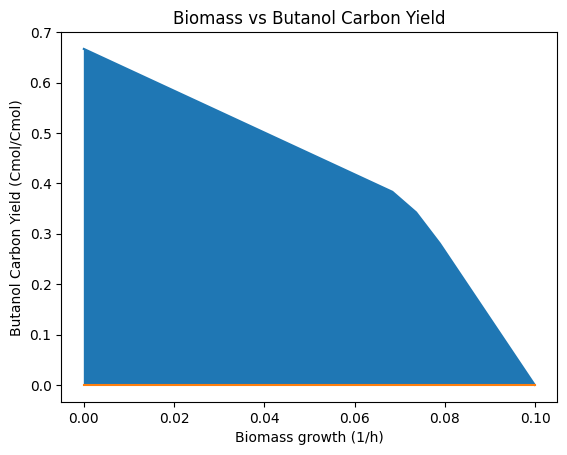

In [ ]:
# btoh,butanol,"['ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4']",btoh,alcohol,accoa,"('PMC', 'PMC3126405')",,C4H10O,,,,,,,
# add exchange rxn for butanol

ex_btoh = Reaction('EX_btoh', lower_bound=0.0, upper_bound=1000.0)
ex_btoh.add_metabolites({model.metabolites.get_by_id('btoh_c'): -1.0})
model.add_reactions([ex_btoh])
heterologous_rxns.add('EX_btoh')

prod_env = carbon_yield_calcs(model, {'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4', 'EX_btoh'}, 'EX_btoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Butanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Butanol Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Isobutanol Carbon Yield')

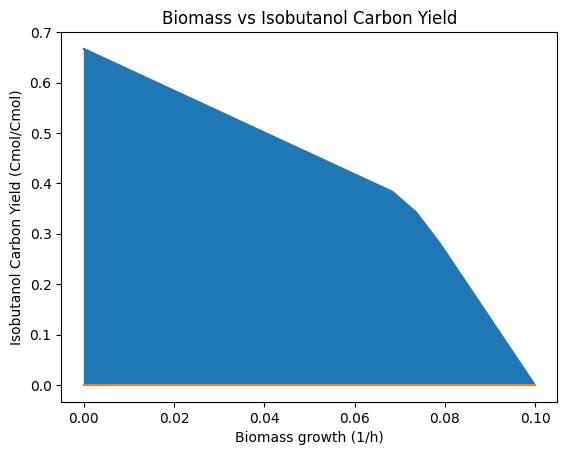

In [ ]:
# ibutoh,Isobutanol,"['ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi']",ibutoh,alcohol,pyr,"('PMID', 18172501)",,C4H10O,,,,,,,

# add exchange rxn for isobutanol

ex_ibutoh = Reaction('EX_ibutoh', lower_bound=0.0, upper_bound=1000.0)
ex_ibutoh.add_metabolites({model.metabolites.get_by_id('ibutoh_c'): -1.0})
model.add_reactions([ex_ibutoh])
heterologous_rxns.add('EX_ibutoh')

prod_env = carbon_yield_calcs(model, {'ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'EX_ibutoh'}, 'EX_ibutoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Isobutanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Isobutanol Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Pentanol Carbon Yield')

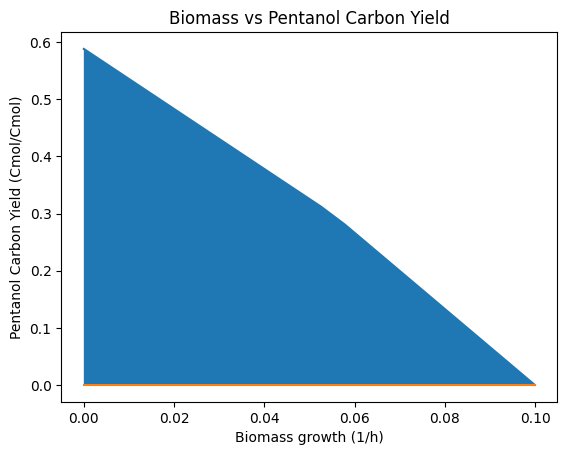

In [ ]:
# ptoh,pentanol,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'PTCOAR', 'ALCDptoh']",ptoh,alcohol,['oaa'],"('PMC', 'PMC3497732')","The key precursor, based on the included reactions is oaa.Similar to propanol pathway.",C5H12O,,,,,,,

ex_ptoh = Reaction('EX_ptoh', lower_bound=0.0, upper_bound=1000.0)
ex_ptoh.add_metabolites({model.metabolites.get_by_id('ptoh_c'): -1.0})
model.add_reactions([ex_ptoh])
heterologous_rxns.add('EX_ptoh')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'PTCOAR', 'ALCDptoh', 'EX_ptoh'}, 'EX_ptoh', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Pentanol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Pentanol Carbon Yield")

Text(0.5, 1.0, 'Biomass vs 1,4-Butanediol Carbon Yield')

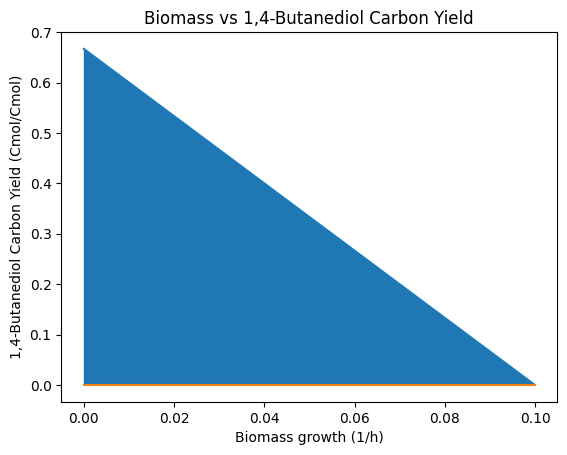

In [ ]:
# 14btd,"1,4-Butanediol","['SUCOAS', 'OXGDC', 'SSCOARx', '4HBDH', '4HBACT', '4HBTALDDH', 'BTDP2']",14btd,alcohol,"['succ', 'akg']","('PMID', 21602812)","['Pathway is provided in Supplementary Data 1, as part of the model used for OptKnock simulations.']",C4H10O2,,,,,,,

ex_14btd = Reaction('EX_14btd', lower_bound=0.0, upper_bound=1000.0)
ex_14btd.add_metabolites({model.metabolites.get_by_id('14btd_c'): -1.0})
model.add_reactions([ex_14btd])
heterologous_rxns.add('EX_14btd')

prod_env = carbon_yield_calcs(model, {'SUCOAS', 'OXGDC', 'SSCOARx', '4HBDH', '4HBACT', '4HBTALDDH', 'BTDP2', 'EX_14btd'}, 'EX_14btd', heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("1,4-Butanediol Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs 1,4-Butanediol Carbon Yield")

In [ ]:
for rxn in model.exchanges:
    print(rxn)

EXBiomass: Biomass[c] --> 
EX0001: Glucose[e] <=> 
EX0002: L_Lactate[e] --> 
EX0003: CO2[e] --> 
EX0004: O2[e] <=> 
EX0005: NH3[e] <=> 
EX0006: Phosphate[e] <=> 
EX0007: Sulfate[e] <=> 
EX0008: Thiamin[e] <=> 
EX0009: Fe2+[e] <=> 
EX0010: Folate[e] <=> 
EX0011: Guanine[e] <=> 
EX0012: H+[e] <=> 
EX0013: H2O[e] <=> 
EX0014: L_Alanine[e] <=> 
EX0015: L_Arginine[e] <=> 
EX0016: L_Cysteine[e] <=> 
EX0017: L_Glutamate[e] <=> 
EX0018: L_Histidine[e] <=> 
EX0019: L_Isoleucine[e] <=> 
EX0020: L_Leucine[e] <=> 
EX0021: L_Methionine[e] <=> 
EX0022: L_Threonine[e] <=> 
EX0023: L_Valine[e] <=> 
EX0024: L_Tyrosine[e] <=> 
EX0025: (R)_3_Hydroxybutanoate[e] --> 
EX0026: 2_Oxoglutarate[e] --> 
EX0027: Acetoin[e] --> 
EX0028: Cellobiose[e] --> 
EX0029: Choline[e] --> 
EX0030: Cytosine[e] --> 
EX0031: D_Alanine[e] --> 
EX0032: D_Fructose[e] --> 
EX0033: D_Gluconate[e] --> 
EX0034: D_Mannose[e] --> 
EX0035: D_Ribose[e] --> 
EX0036: Ethanol[e] --> 
EX0037: Formate[e] --> 
EX0038: Fumarate[e] --> 
EX0039: 

Text(0.5, 1.0, 'Biomass vs Pyruvate Carbon Yield')

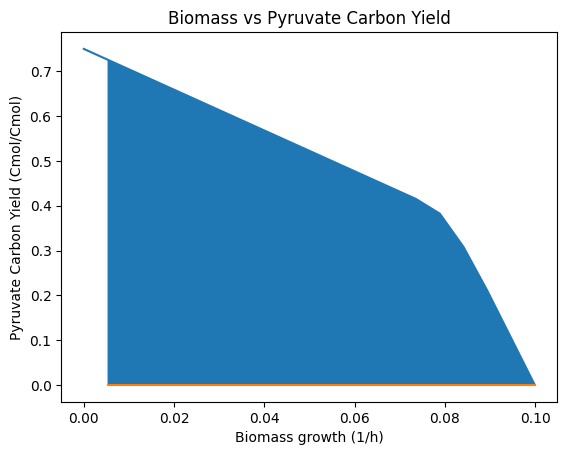

In [ ]:
# pyr,Pyruvate,[],pyr,organic acid,pyr,"('PMC', 'PMC5055523')",,C3H3O3,,,,,,,

# ex_pyr = Reaction('EX_pyr', lower_bound=0.0, upper_bound=1000.0)
# ex_pyr.add_metabolites({model.metabolites.get_by_id('Pyruvate[c]'): -1.0})
# model.add_reactions([ex_pyr])
# heterologous_rxns.add('EX_pyr')

prod_env = carbon_yield_calcs(model, set(), model.reactions.get_by_id('EX0070'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Pyruvate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Pyruvate Carbon Yield")

In [ ]:
for met in model.metabolites:
    print(met)

(2E)_Octadecenoyl_ACP[c]
(3R)_3_Hydroxybutanoyl_ACP[c]
(3R)_3_Hydroxydecanoyl_ACP[c]
(3R)_3_Hydroxyoctanoyl_ACP[c]
(3R)_3_Hydroxypalmitoyl_ACP[c]
(3R)_3_Hydroxytetradecanoyl_ACP[c]
(R)_3_Amino_2_methylpropanoate[c]
(R)_3_Hydroxy_3_methyl_2_oxopentanoate[c]
(R)_3_Hydroxybutanoate[c]
(R)_3_Hydroxybutanoate[e]
(R)_3_Hydroxydodecanoyl_ACP[c]
(R)_3_Hydroxyoctadecanoyl_ACP[c]
(R)_3_Ureidoisobutyrate[c]
(R)_4_Phosphopantothenoyl_L_cysteine[c]
(R)_5_6_Dihydrothymine[c]
(R)_5_Diphosphomevalonate[c]
(R)_5_Phosphomevalonate[c]
(R)_Mevalonate[c]
(S)_2_Acetolactate[c]
(S)_3_Hydroxybutanoyl_CoA[c]
(S)_3_Hydroxydodecanoyl_CoA[c]
(S)_3_Hydroxyhexadecanoyl_CoA[c]
(S)_3_Hydroxyoctanoyl_CoA[c]
(S)_3_Hydroxytetradecanoyl_CoA[c]
(S)_Hydroxydecanoyl_CoA[c]
(S)_Hydroxyhexanoyl_CoA[c]
10_Formyl_THF[c]
1_(2_carboxyphenylamino)_1_deoxyribulose_5_phosphate[c]
1_2_Diacyl_sn_glycerol[c]
1_3_Bisphospho_D_glycerate[c]
1_4_Dihydroxy_2_naphthoyl_CoA[c]
1_Acyl_sn_glycero_3_phosphocholine[c]
1_Acyl_sn_glycero_3_phosphoe

Text(0.5, 1.0, 'Biomass vs D-Lactate Carbon Yield')

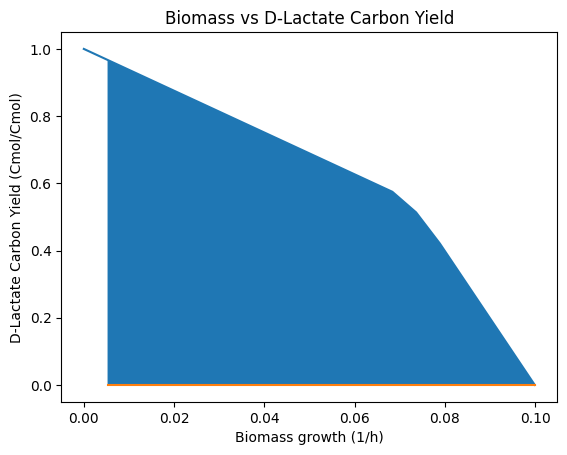

In [ ]:
# lac__D,D-Lactate,['LDH_D'],lac__D,organic acid,pyr,"('PMID', 24884499)",,C3H5O3,,,,,,,

ex_lac__D = Reaction('EX_lac__D', lower_bound=0.0, upper_bound=1000.0)
ex_lac__D.add_metabolites({model.metabolites.get_by_id('lac__D_c'): -1.0})
model.add_reactions([ex_lac__D])
heterologous_rxns.add('EX_lac__D')

prod_env = carbon_yield_calcs(model, {'LDH_D', 'EX_lac__D'}, model.reactions.get_by_id('EX_lac__D'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("D-Lactate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs D-Lactate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Acetate Carbon Yield')

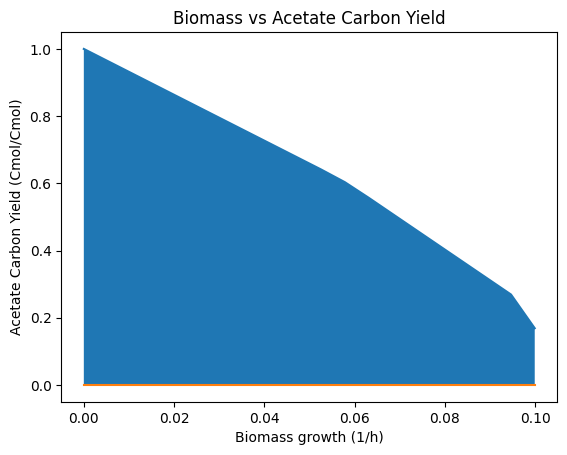

In [ ]:
# ac,acetate,"['PTAr', 'ACKr']",ac,organic acid,accoa,,native E. coli pathway,C2H3O2,,,,,,,

prod_env = carbon_yield_calcs(model, {'PTAr', 'ACKr', 'EX0068'}, model.reactions.get_by_id('EX0068'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Acetate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Acetate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Adipic Acid Carbon Yield')

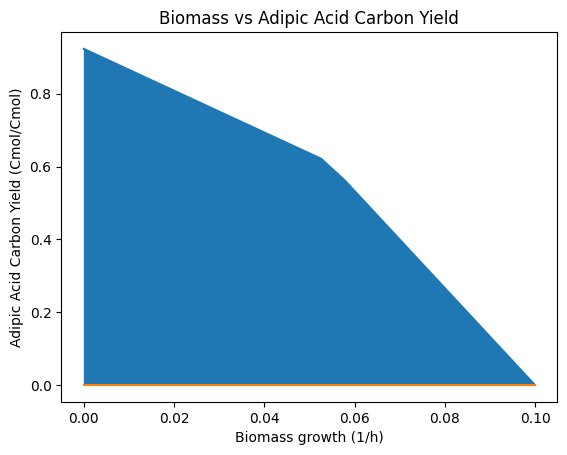

In [ ]:
# adpac,Adipic acid,"['3OXCOAT', 'HADPCOADH3', 'DHACOAH', 'TER', 'PTB', 'BUK1']",adpac,organic acid,"['accoa', 'succoa']","('PMID', 24895214)",,C6H8O4,,,,,,,

ex_adpac = Reaction('EX_adpac', lower_bound=0.0, upper_bound=1000.0)
ex_adpac.add_metabolites({model.metabolites.get_by_id('adpac_c'): -1.0})
model.add_reactions([ex_adpac])
heterologous_rxns.add('EX_adpac')

prod_env = carbon_yield_calcs(model, {'3OXCOAT', 'HADPCOADH3', 'DHACOAH', 'TER', 'PTB', 'BUK1', 'EX_adpac'}, model.reactions.get_by_id('EX_adpac'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Adipic Acid Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Adipic Acid Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Ethyl Acetate Carbon Yield')

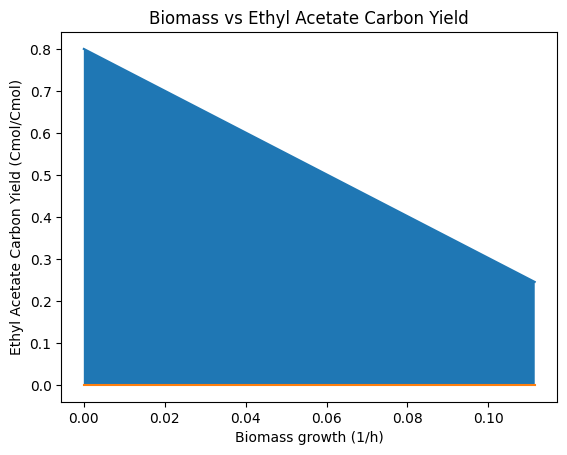

In [ ]:
# etylace,Ethyl acetate,"['ACALD', 'PYRDC', 'AATetylace']",etylace,ester,"['pyr', 'accoa']","('PMC', 'PMC4411949')",,C4H8O2,,,,,,,

ex_etylace = Reaction('EX_etylace', lower_bound=0.0, upper_bound=1000.0)
ex_etylace.add_metabolites({model.metabolites.get_by_id('etylace_c'): -1.0})
model.add_reactions([ex_etylace])
heterologous_rxns.add('EX_etylace')

prod_env = carbon_yield_calcs(model, {'ACALD', 'PYRDC', 'AATetylace', 'EX_etylace'}, model.reactions.get_by_id('EX_etylace'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethyl Acetate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethyl Acetate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Propyl Acetate Carbon Yield')

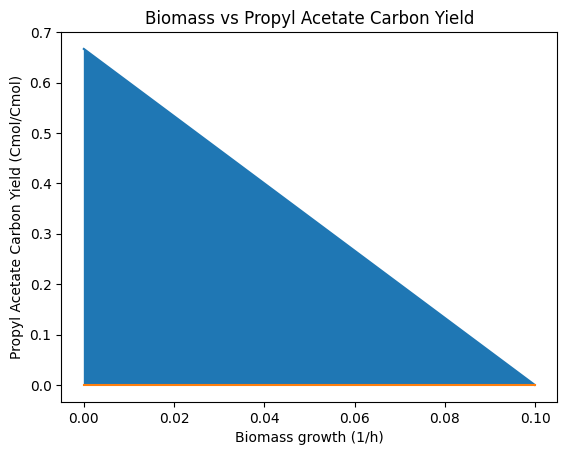

In [ ]:
# ppylace,Propyl acetate,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir', 'AATppylace']",ppylace,ester,"['oaa', 'accoa']","('PMC', 'PMC4411949')","The key precursor, based on the included reactions is oaa.",C5H10O2,,,,,,,

ex_ppylace = Reaction('EX_ppylace', lower_bound=0.0, upper_bound=1000.0)
ex_ppylace.add_metabolites({model.metabolites.get_by_id('ppylace_c'): -1.0})
model.add_reactions([ex_ppylace])
heterologous_rxns.add('EX_ppylace')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir', 'AATppylace', 'EX_ppylace'}, model.reactions.get_by_id('EX_ppylace'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Propyl Acetate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Propyl Acetate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Isobutyl Acetate Carbon Yield')

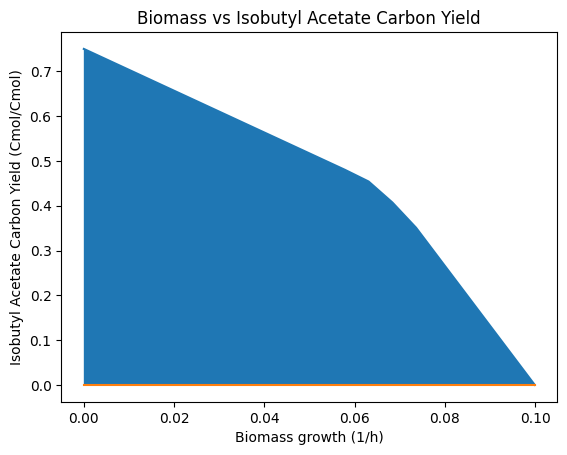

In [ ]:
# ibutylace,Isobutyl acetate,"['ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'AATibutylace']",ibutylace,ester,"['pyr', 'accoa']","('PMC', 'PMC4411949')",,C6H12O2,,,,,,,

ex_ibutylace = Reaction('EX_ibutylace', lower_bound=0.0, upper_bound=1000.0)
ex_ibutylace.add_metabolites({model.metabolites.get_by_id('ibutylace_c'): -1.0})
model.add_reactions([ex_ibutylace])
heterologous_rxns.add('EX_ibutylace')

prod_env = carbon_yield_calcs(model, {'ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'AATibutylace', 'EX_ibutylace'}, model.reactions.get_by_id('EX_ibutylace'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Isobutyl Acetate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Isobutyl Acetate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Ethyl Butyrate Carbon Yield')

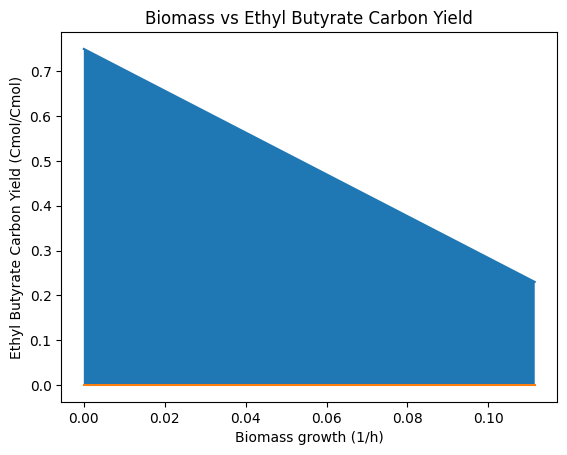

In [ ]:
# etylbte,Ethyl butanoate,"['ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ACALD', 'PYRDC', 'AATetylbte']",etylbte,ester,"['accoa', 'pyr']","('PMID', 25281839)",,C6H12O2,,,,,,,

ex_etylbte = Reaction('EX_etylbte', lower_bound=0.0, upper_bound=1000.0)
ex_etylbte.add_metabolites({model.metabolites.get_by_id('etylbte_c'): -1.0})
model.add_reactions([ex_etylbte])
heterologous_rxns.add('EX_etylbte')

prod_env = carbon_yield_calcs(model, {'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ACALD', 'PYRDC', 'AATetylbte', 'EX_etylbte'}, model.reactions.get_by_id('EX_etylbte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethyl Butyrate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethyl Butyrate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Propyl Butyrate Carbon Yield')

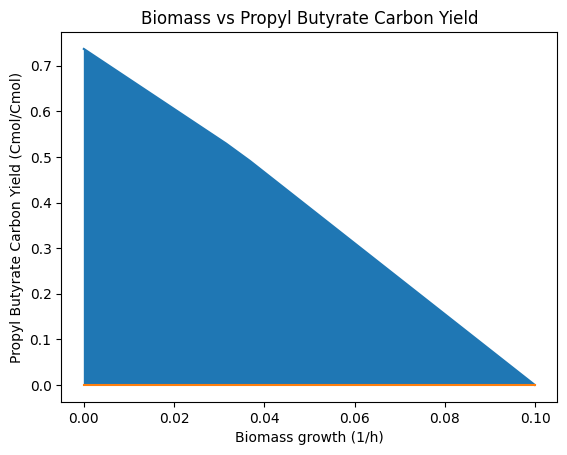

In [ ]:
# ppylbte,Propyl butanoate,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir', 'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'AATppylbte']",ppylbte,ester,"['oaa', 'accoa']","('PMID', 25281839)",,C7H14O2,,,,,,,

ex_ppylbte = Reaction('EX_ppylbte', lower_bound=0.0, upper_bound=1000.0)
ex_ppylbte.add_metabolites({model.metabolites.get_by_id('ppylbte_c'): -1.0})
model.add_reactions([ex_ppylbte])
heterologous_rxns.add('EX_ppylbte')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'ALDD3procoa', 'ALCD3ir', 'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'AATppylbte', 'EX_ppylbte'}, model.reactions.get_by_id('EX_ppylbte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Propyl Butyrate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Propyl Butyrate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Butyl Butyrate Carbon Yield')

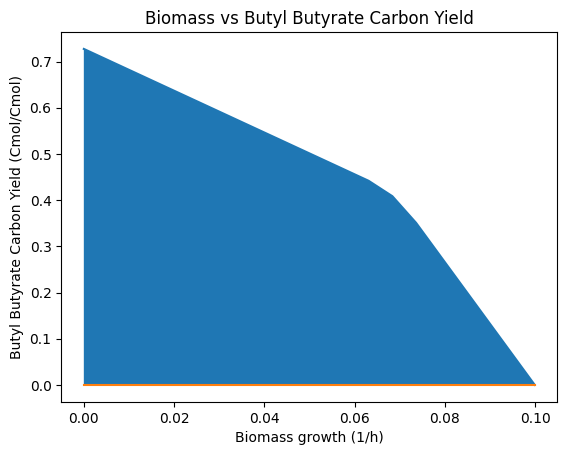

In [ ]:
# btylbte,Butyl butanoate,"['ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4', 'AATbtylbte']",btylbte,ester,accoa,"('PMID', 25281839)",,C8H16O2,,,,,,,

ex_btylbte = Reaction('EX_btylbte', lower_bound=0.0, upper_bound=1000.0)
ex_btylbte.add_metabolites({model.metabolites.get_by_id('btylbte_c'): -1.0})
model.add_reactions([ex_btylbte])
heterologous_rxns.add('EX_btylbte')

prod_env = carbon_yield_calcs(model, {'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'ALCD4', 'AATbtylbte', 'EX_btylbte'}, model.reactions.get_by_id('EX_btylbte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Butyl Butyrate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Butyl Butyrate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Isobutyl Butyrate Carbon Yield')

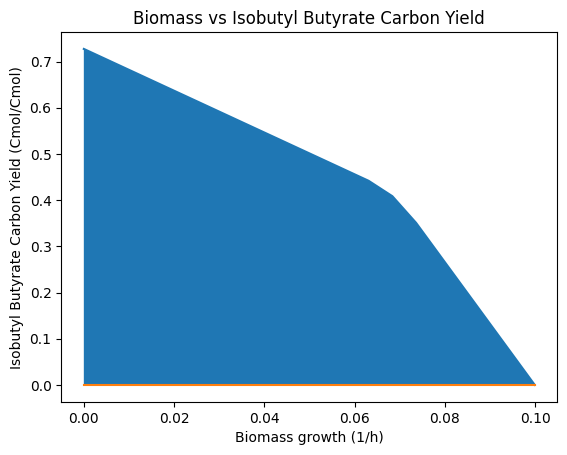

In [ ]:
# ibutylbte,Isobutyl butanoate,"['ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'AATibutylbte']",ibutylbte,ester,"['pyr', 'accoa']","('PMID', 25281839)",,C8H16O2,,,,,,,

ex_ibutylbte = Reaction('EX_ibutylbte', lower_bound=0.0, upper_bound=1000.0)
ex_ibutylbte.add_metabolites({model.metabolites.get_by_id('ibutylbte_c'): -1.0})
model.add_reactions([ex_ibutylbte])
heterologous_rxns.add('EX_ibutylbte')

prod_env = carbon_yield_calcs(model, {'ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'ACACT1r', 'HACD1', 'ECOAH1', 'ACOAD1', 'BTCOARx', 'AATibutylbte', 'EX_ibutylbte'}, model.reactions.get_by_id('EX_ibutylbte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Isobutyl Butyrate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Isobutyl Butyrate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Ethyl Pentanoate Carbon Yield')

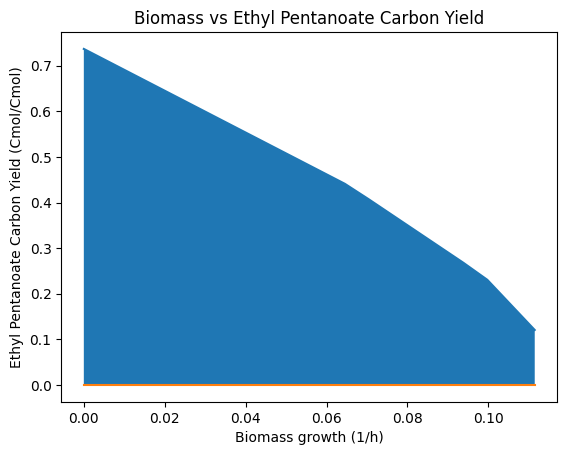

In [ ]:
# etylpte,Ethyl pentanoate,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'ACALD', 'PYRDC', 'AATetylpte']",etylpte,ester,"['oaa', 'pyr']","('PMC', 'PMC5678828')",In the referenced study pentanoate is provided externally and converted intracellularly to pentanoyl-coa. Here we use the pentanol pathway to obtain pentanoyl-coa,C7H14O2,,,,,,,

ex_etylpte = Reaction('EX_etylpte', lower_bound=0.0, upper_bound=1000.0)
ex_etylpte.add_metabolites({model.metabolites.get_by_id('etylpte_c'): -1.0})
model.add_reactions([ex_etylpte])
heterologous_rxns.add('EX_etylpte')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'ACALD', 'PYRDC', 'AATetylpte', 'EX_etylpte'}, model.reactions.get_by_id('EX_etylpte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Ethyl Pentanoate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Ethyl Pentanoate Carbon Yield")


Text(0.5, 1.0, 'Biomass vs Isobutyl Pentanoate Carbon Yield')

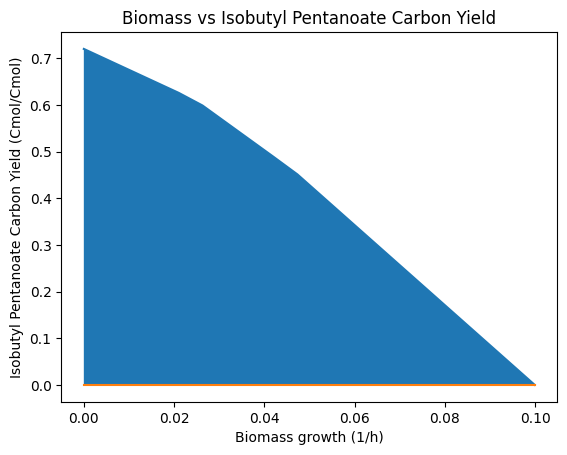

In [ ]:
# ibutylpte,Isobutyl pentanoate,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'AATibutylpte']",ibutylpte,ester,"['oaa', 'pyr']","('PMC', 'PMC5678828')",In the referenced study pentanoate is provided externally and converted intracellularly to pentanoyl-coa. Here we use the pentanol pathway to obtain pentanoyl-coa,C9H18O2,,,,,,,

ex_ibutylpte = Reaction('EX_ibutylpte', lower_bound=0.0, upper_bound=1000.0)
ex_ibutylpte.add_metabolites({model.metabolites.get_by_id('ibutylpte_c'): -1.0})
model.add_reactions([ex_ibutylpte])
heterologous_rxns.add('EX_ibutylpte')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'ACLS', 'KARA1', 'DHAD1', 'OIVD2', 'IBUTCOA', 'ALCD23xi', 'AATibutylpte', 'EX_ibutylpte'}, model.reactions.get_by_id('EX_ibutylpte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Isobutyl Pentanoate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Isobutyl Pentanoate Carbon Yield")

Text(0.5, 1.0, 'Biomass vs Pentyl Pentanoate Carbon Yield')

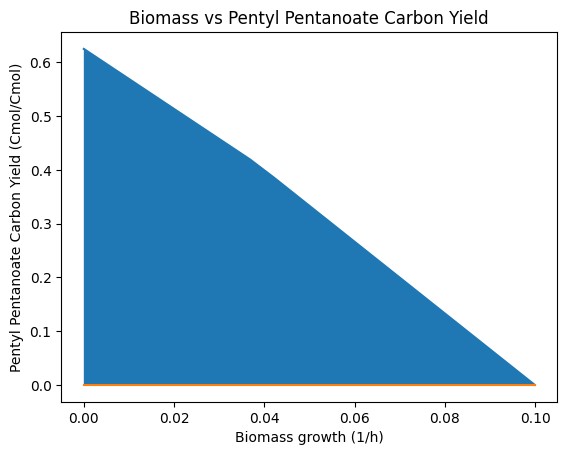

In [ ]:
# ptylpte,Pentyl pentanoate,"['ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'PTCOAR', 'ALCDptoh', 'AATptylpte']",ptylpte,ester,['oaa'],"('PMC', 'PMC5678828')",In the referenced study pentanoate is provided externally and converted intracellularly to pentanoyl-coa. Here we use the pentanol pathway to obtain pentanoyl-coa,C10H20O2,,,,,,,

ex_ptylpte = Reaction('EX_ptylpte', lower_bound=0.0, upper_bound=1000.0)
ex_ptylpte.add_metabolites({model.metabolites.get_by_id('ptylpte_c'): -1.0})
model.add_reactions([ex_ptylpte])
heterologous_rxns.add('EX_ptylpte')

prod_env = carbon_yield_calcs(model, {'ASPTA', 'ASPK', 'ASAD', 'HSDy', 'HSK', 'THRS', 'THRD_L', 'OBDHc', 'VCACT', 'HVCD', 'VECOAH', 'VCOAD2', 'PTCOAR', 'ALCDptoh', 'AATptylpte', 'EX_ptylpte'}, model.reactions.get_by_id('EX_ptylpte'), heterologous_rxns)

plt.fill_between(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_maximum'])
plt.plot(prod_env['EXBiomass'], prod_env['carbon_yield_minimum'])

plt.xlabel("Biomass growth (1/h)")
plt.ylabel("Pentyl Pentanoate Carbon Yield (Cmol/Cmol)")
plt.title("Biomass vs Pentyl Pentanoate Carbon Yield")

In [ ]:
bad = {}
for rid in heterologous_rxns:
    if rid.startswith('EX_'):
        continue
    imb = model.reactions.get_by_id(rid).check_mass_balance()
    if imb:
        bad[rid] = imb

for rid, imb in bad.items():
    print(f"{rid} {imb}  :  {model.reactions.get_by_id(rid).reaction}")

4HBACT {'charge': -3.0, 'H': -3.0}  :  4hdxbutn_c + Acetyl_CoA[c] --> 4hbutcoa_c + Acetate[c]
BUK1 {'charge': 1.0, 'H': 1.0}  :  ADP[c] + adpp_c --> ATP[c] + adpac_c
PTB {'charge': 2.0, 'H': 2.0}  :  Phosphate[c] + adpcoa_c --> CoA[c] + adpp_c
AATetylpte {'charge': 4.0, 'H': 4.0}  :  Ethanol[c] + ptcoa_c --> CoA[c] + etylpte_c
PTCOAR {'charge': 4.0, 'H': 4.0}  :  H+[c] + NADH[c] + ptcoa_c --> CoA[c] + NAD[c] + ptal_c
LDH_D {'charge': 1.0, 'H': 1.0}  :  NAD[c] + lac__D_c <=> H+[c] + NADH[c] + Pyruvate[c]
PYRDC {'H': -1.0}  :  H+[c] + Pyruvate[c] --> Acetaldehyde[c] + CO2[c]
OIVD2 {'H': -1.0}  :  3_Methyl_2_oxobutanoate[c] + CoA[c] + NAD[c] --> CO2[c] + Isobutyryl_CoA[c] + NADH[c]
AATibutylpte {'charge': 4.0, 'H': 4.0}  :  ibutoh_c + ptcoa_c --> CoA[c] + ibutylpte_c
3OXCOAT {'charge': 5.0, 'H': 5.0}  :  CoA[c] + oxadpcoa_c <=> Acetyl_CoA[c] + Succinyl_CoA[c]
AATptylpte {'charge': 4.0, 'H': 4.0}  :  ptcoa_c + ptoh_c --> CoA[c] + ptylpte_c
OBDHc {'H': -1.0}  :  2_Oxobutyrate[c] + CoA[c] + 

In [ ]:
for met in model.metabolites:
    print(met.id, met.charge)

(2E)_Octadecenoyl_ACP[c] 0
(3R)_3_Hydroxybutanoyl_ACP[c] 0
(3R)_3_Hydroxydecanoyl_ACP[c] 0
(3R)_3_Hydroxyoctanoyl_ACP[c] 0
(3R)_3_Hydroxypalmitoyl_ACP[c] 0
(3R)_3_Hydroxytetradecanoyl_ACP[c] 0
(R)_3_Amino_2_methylpropanoate[c] 0
(R)_3_Hydroxy_3_methyl_2_oxopentanoate[c] 0
(R)_3_Hydroxybutanoate[c] 0
(R)_3_Hydroxybutanoate[e] 0
(R)_3_Hydroxydodecanoyl_ACP[c] 0
(R)_3_Hydroxyoctadecanoyl_ACP[c] 0
(R)_3_Ureidoisobutyrate[c] 0
(R)_4_Phosphopantothenoyl_L_cysteine[c] 0
(R)_5_6_Dihydrothymine[c] 0
(R)_5_Diphosphomevalonate[c] 0
(R)_5_Phosphomevalonate[c] 0
(R)_Mevalonate[c] 0
(S)_2_Acetolactate[c] 0
(S)_3_Hydroxybutanoyl_CoA[c] 0
(S)_3_Hydroxydodecanoyl_CoA[c] 0
(S)_3_Hydroxyhexadecanoyl_CoA[c] 0
(S)_3_Hydroxyoctanoyl_CoA[c] 0
(S)_3_Hydroxytetradecanoyl_CoA[c] 0
(S)_Hydroxydecanoyl_CoA[c] 0
(S)_Hydroxyhexanoyl_CoA[c] 0
10_Formyl_THF[c] 0
1_(2_carboxyphenylamino)_1_deoxyribulose_5_phosphate[c] 0
1_2_Diacyl_sn_glycerol[c] 0
1_3_Bisphospho_D_glycerate[c] 0
1_4_Dihydroxy_2_naphthoyl_CoA[c] 0
1_Ac

In [ ]:
for rxn in heterologous_rxns:
    print(model.reactions.get_by_id(rxn))

KARA1: 2_3_Dihydroxy_isovalerate[c] + NADP[c] <=> (S)_2_Acetolactate[c] + H+[c] + NADPH[c]
4HBACT: 4hdxbutn_c + Acetyl_CoA[c] --> 4hbutcoa_c + Acetate[c]
TER: 23dhacoa_c + H+[c] + NADH[c] --> NAD[c] + adpcoa_c
ALCD23xi: 2mppal_c + H+[c] + NADH[c] --> NAD[c] + ibutoh_c
ALDD3procoa: H+[c] + NADH[c] + Propanoyl_CoA[c] --> CoA[c] + NAD[c] + ppal_c
BUK1: ADP[c] + adpp_c --> ATP[c] + adpac_c
BTCOARx: Butanoyl_CoA[c] + H+[c] + NADH[c] <=> CoA[c] + NAD[c] + btal_c
EX_ibutylpte: ibutylpte_c --> 
ECOAH1: (S)_3_Hydroxybutanoyl_CoA[c] <=> Crotonoyl_CoA[c] + H2O[c]
BTDP2: 4hdxbld_c + H+[c] + NADH[c] --> 14btd_c + NAD[c]
SUCOAS: ATP[c] + CoA[c] + Succinate[c] <=> ADP[c] + Phosphate[c] + Succinyl_CoA[c]
THRD_L: L_Threonine[c] --> 2_Oxobutyrate[c] + NH3[c]
EX_btoh: btoh_c --> 
PTAr: Acetyl_CoA[c] + Phosphate[c] <=> Acetylphosphate[c] + CoA[c]
EX_ppoh: ppoh_c --> 
VCOAD2: H+[c] + NADH[c] + pt2coa_c <=> NAD[c] + ptcoa_c
EX_ibutylace: ibutylace_c --> 
AATppylace: Acetyl_CoA[c] + ppoh_c --> CoA[c] + ppyla